# Notebook 2 — Exploratory Data Analysis (EDA)

## Coal Demand Forecasting — CRISP-ML(Q) Framework

**Objective:** Perform comprehensive EDA on the raw coal demand dataset to understand patterns, identify data quality issues, and inform feature engineering decisions.

### What this notebook covers:
1. **Descriptive Statistics** — Summary statistics, data types, shape
2. **SIPOC Diagram** — Suppliers, Inputs, Process, Outputs, Customers
3. **Value Chain Diagram** — Coal Mine → Power Generation → Grid
4. **Distribution Analysis** — Histograms for each numeric feature
5. **Trend Analysis** — 30-day and 90-day rolling means
6. **Seasonality Decomposition** — Additive decomposition (period=365)
7. **Monthly & Weekly Patterns** — Boxplots by month, day of week
8. **Quarterly Trends** — Year-over-year quarterly comparison
9. **Holiday Impact** — Consumption: holidays vs normal days
10. **ACF/PACF Plots** — For ARIMA parameter identification
11. **Correlation Heatmap** — Feature inter-relationships
12. **Pairplot** — Key variable scatter plots
13. **Outlier Detection** — Boxplots using IQR method
14. **Missing Values Visualization** — Pattern and counts
15. **Data Issues Report** — Missing values, outliers, stationarity, skewness

---

## 2.1 Setup & Load Raw Data

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

# Inline plotting with high-quality defaults
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Load config constants ────────────────────────────────────────────────────
from src.config import RAW_DATA_FILE, IQR_MULTIPLIER, REPORTS_DIR

# Create reports directory if needed
os.makedirs(REPORTS_DIR, exist_ok=True)

# ── Load raw data ────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_DATA_FILE)
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")

Dataset shape: 1096 rows x 8 columns
Date range: 2022-01-01 to 2024-12-31
Columns: ['date', 'power_generation_mw', 'coal_consumption_tonnes', 'temperature_c', 'coal_price_inr', 'inventory_level_tonnes', 'is_holiday', 'is_weekend']


## 2.2 Descriptive Statistics

Before any visualization, we inspect the dataset shape, data types, and summary statistics to understand the data at a glance.

In [2]:
# ── Data types and non-null counts ───────────────────────────────────────────
print("Data Types & Non-Null Counts:")
print("=" * 50)
for col in df.columns:
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    print(f"  {col:<30} {str(df[col].dtype):<12} {non_null}/{len(df)} ({pct:.1f}%)")

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Missing value %: {df.isnull().sum().sum() / df.size * 100:.2f}%")

Data Types & Non-Null Counts:
  date                           datetime64[ns] 1096/1096 (100.0%)
  power_generation_mw            float64      1086/1096 (99.1%)
  coal_consumption_tonnes        float64      1086/1096 (99.1%)
  temperature_c                  float64      1086/1096 (99.1%)
  coal_price_inr                 float64      1086/1096 (99.1%)
  inventory_level_tonnes         float64      1086/1096 (99.1%)
  is_holiday                     int64        1096/1096 (100.0%)
  is_weekend                     int64        1096/1096 (100.0%)

Total missing values: 50
Missing value %: 0.57%


In [3]:
# ── Summary statistics table ──────────────────────────────────────────────────
desc = df.describe().round(2)
print("Summary Statistics:")
display(desc)

Summary Statistics:


,date,power_generation_mw,coal_consumption_tonnes,temperature_c,coal_price_inr,inventory_level_tonnes,is_holiday,is_weekend
count,1096,1086.00,1086.00,1086.00,1086.00,1086.00,1096.00,1096.00
mean,2023-07-02 12:00:00,539.13,243.70,24.95,10700.52,3253.26,0.04,0.29
min,2022-01-01 00:00:00,285.66,126.88,5.00,8051.29,1732.48,0.00,0.00
25%,2022-10-01 18:00:00,492.59,219.39,14.72,9666.24,2509.64,0.00,0.00
50%,2023-07-02 12:00:00,530.30,239.09,25.20,11033.46,3254.26,0.00,0.00
75%,2024-04-01 06:00:00,572.30,259.74,35.30,11424.23,4013.92,0.00,1.00
max,2024-12-31 00:00:00,1801.38,795.89,45.20,12152.17,5000.00,1.00,1.00
std,NaN,127.51,63.98,10.98,985.84,869.72,0.19,0.45


In [4]:
# ── First 5 and last 5 rows ──────────────────────────────────────────────────
print("First 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,date,power_generation_mw,coal_consumption_tonnes,temperature_c,coal_price_inr,inventory_level_tonnes,is_holiday,is_weekend
0,2022-01-01,480.97,219.68,9.5,8090.32,5000.00,0,1
1,2022-01-02,486.53,228.60,8.0,8078.85,4771.40,0,1
2,2022-01-03,580.11,250.96,10.6,8111.22,4520.44,0,0
3,2022-01-04,595.45,275.24,8.4,8117.76,4245.20,0,0
4,2022-01-05,584.80,271.34,8.7,8133.79,3973.86,0,0



Last 5 rows:


,date,power_generation_mw,coal_consumption_tonnes,temperature_c,coal_price_inr,inventory_level_tonnes,is_holiday,is_weekend
1091,2024-12-27,574.48,276.13,11.8,11874.48,4722.30,0,0
1092,2024-12-28,481.30,208.68,8.6,11898.04,4513.61,0,1
1093,2024-12-29,492.90,233.53,11.1,11913.96,4280.09,0,1
1094,2024-12-30,561.70,250.73,13.5,11968.71,4029.36,0,0
1095,2024-12-31,564.04,259.28,8.8,11940.70,3770.08,0,0


## 2.3 SIPOC Diagram

**SIPOC** (Suppliers, Inputs, Process, Outputs, Customers) is a high-level process map used in Six Sigma and CRISP-ML(Q) to define the scope and stakeholders of the forecasting system.

- **Suppliers:** Coal India Ltd (CIL), private mines, international importers
- **Inputs:** Raw coal supply, power generation schedules, weather forecasts, historical data
- **Process:** Data collection, Feature engineering, ML model training, Forecasting, Inventory optimization
- **Outputs:** Daily demand forecasts, procurement recommendations, inventory alerts, cost reports
- **Customers:** Thermal power plant operators, procurement team, grid operators, regulators

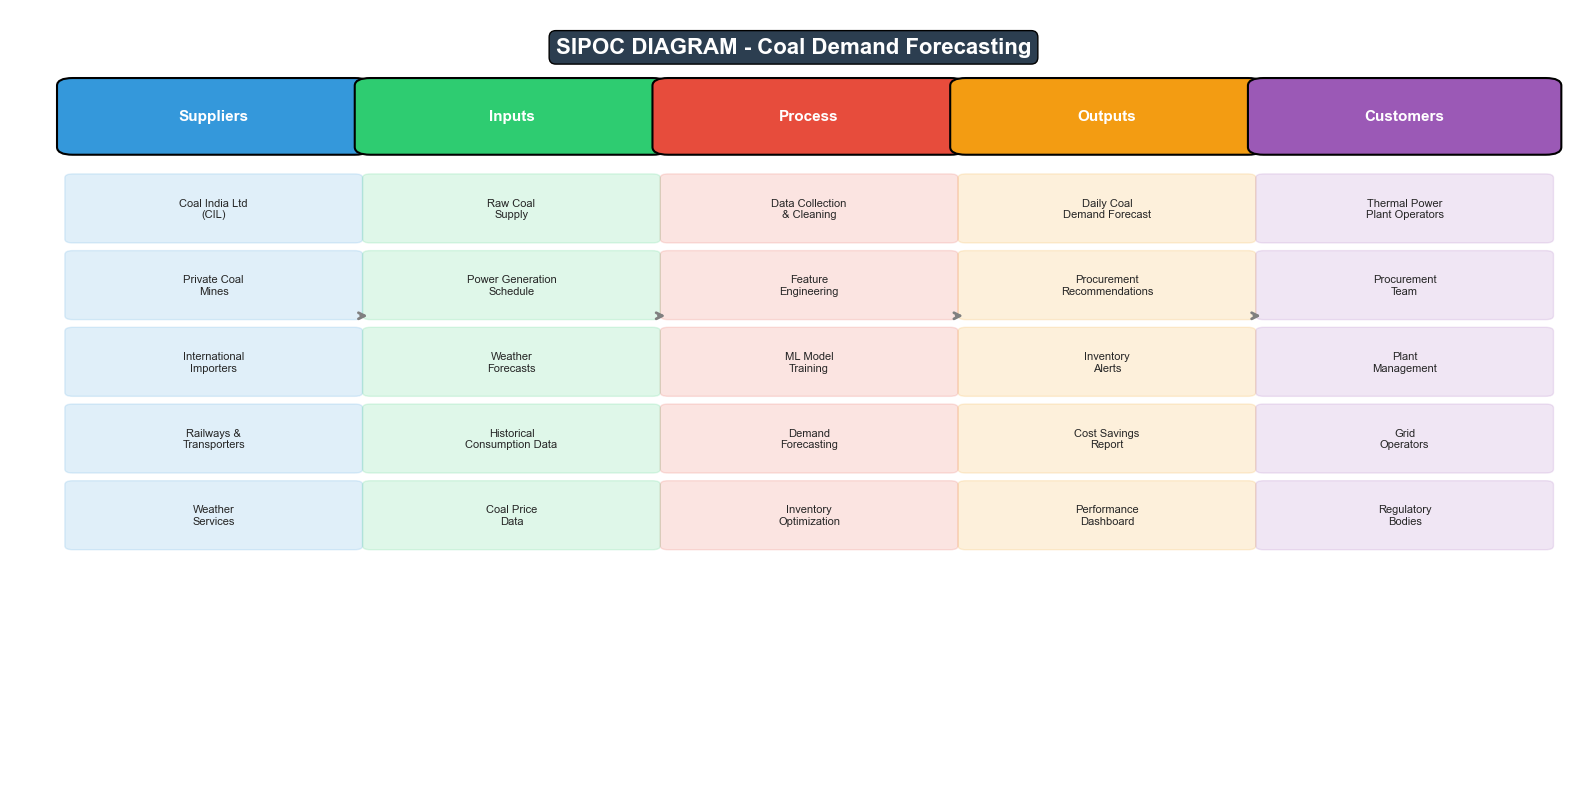

SIPOC diagram generated and saved.


In [5]:
# ── SIPOC Diagram ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title bar
ax.text(5, 9.5, 'SIPOC DIAGRAM - Coal Demand Forecasting',
        ha='center', va='center', fontsize=16, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#2C3E50', edgecolor='black'),
        color='white')

# Column definitions
headers = ['Suppliers', 'Inputs', 'Process', 'Outputs', 'Customers']
colors = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6']
content = [
    ['Coal India Ltd\n(CIL)', 'Private Coal\nMines', 'International\nImporters',
     'Railways &\nTransporters', 'Weather\nServices'],
    ['Raw Coal\nSupply', 'Power Generation\nSchedule', 'Weather\nForecasts',
     'Historical\nConsumption Data', 'Coal Price\nData'],
    ['Data Collection\n& Cleaning', 'Feature\nEngineering', 'ML Model\nTraining',
     'Demand\nForecasting', 'Inventory\nOptimization'],
    ['Daily Coal\nDemand Forecast', 'Procurement\nRecommendations', 'Inventory\nAlerts',
     'Cost Savings\nReport', 'Performance\nDashboard'],
    ['Thermal Power\nPlant Operators', 'Procurement\nTeam', 'Plant\nManagement',
     'Grid\nOperators', 'Regulatory\nBodies'],
]

col_width = 1.8
start_x = 0.4
header_y = 8.2
row_height = 1.0

# Draw each SIPOC column
for i, (header, color) in enumerate(zip(headers, colors)):
    x = start_x + i * col_width + i * 0.1
    # Header box
    rect = mpatches.FancyBboxPatch((x, header_y), col_width, 0.8,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + col_width / 2, header_y + 0.4, header,
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    # Content rows
    for j, item in enumerate(content[i]):
        y = header_y - 1.2 - j * row_height
        rect = mpatches.FancyBboxPatch((x, y), col_width, 0.8,
                                        boxstyle='round,pad=0.05',
                                        facecolor=color, alpha=0.15,
                                        edgecolor=color, linewidth=1)
        ax.add_patch(rect)
        ax.text(x + col_width / 2, y + 0.4, item,
                ha='center', va='center', fontsize=8, wrap=True)

# Arrows between columns
for i in range(4):
    x_start = start_x + (i + 1) * col_width + i * 0.1 + 0.02
    x_end = x_start + 0.08
    ax.annotate('', xy=(x_end, 6.0), xytext=(x_start, 6.0),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'sipoc_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()
print("SIPOC diagram generated and saved.")

## 2.4 Value Chain Diagram

The **value chain** traces the journey of coal from mine to electricity grid. Our forecasting model sits between the **Storage & Inventory** and **Combustion** stages, optimizing coal procurement to meet power generation demand.

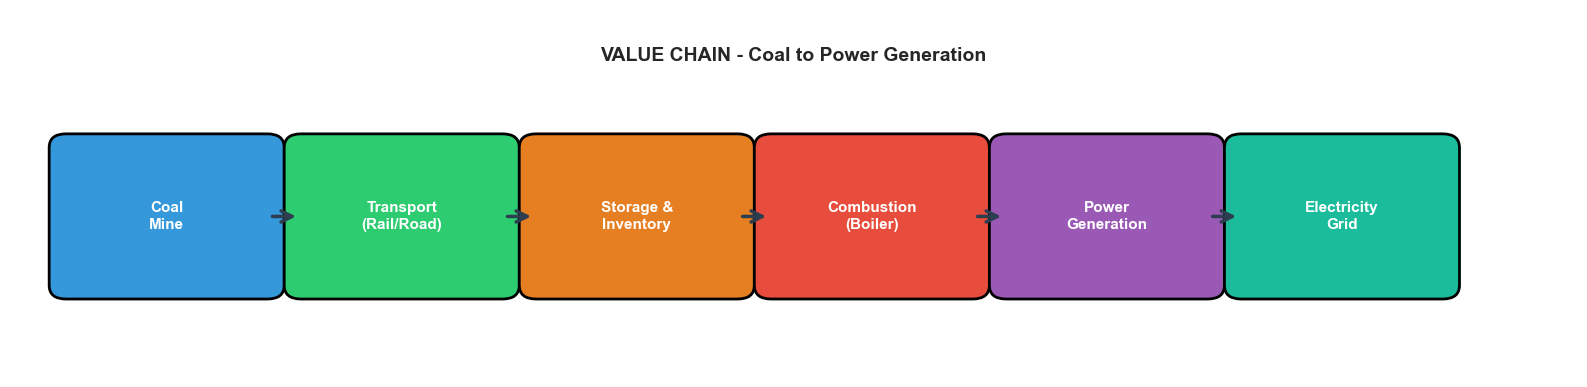

Value chain diagram generated and saved.


In [6]:
# ── Value Chain Diagram ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')

ax.text(7, 3.5, 'VALUE CHAIN - Coal to Power Generation',
        ha='center', va='center', fontsize=14, fontweight='bold')

stages = [
    ('Coal\nMine', '#3498DB'), ('Transport\n(Rail/Road)', '#2ECC71'),
    ('Storage &\nInventory', '#E67E22'), ('Combustion\n(Boiler)', '#E74C3C'),
    ('Power\nGeneration', '#9B59B6'), ('Electricity\nGrid', '#1ABC9C'),
]

box_w, box_h = 1.8, 1.5
gap = 0.3
start_x = 0.5
y = 1.0

for i, (label, color) in enumerate(stages):
    x = start_x + i * (box_w + gap)
    rect = mpatches.FancyBboxPatch((x, y), box_w, box_h,
                                    boxstyle='round,pad=0.15',
                                    facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + box_w / 2, y + box_h / 2, label,
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    # Arrow to next stage
    if i < len(stages) - 1:
        arrow_x = x + box_w + 0.02
        ax.annotate('', xy=(arrow_x + gap - 0.04, y + box_h / 2),
                    xytext=(arrow_x, y + box_h / 2),
                    arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2.5, mutation_scale=20))

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'value_chain.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Value chain diagram generated and saved.")

## 2.5 Distribution Analysis

Histograms with **KDE** (Kernel Density Estimation) overlays for each numeric feature. Vertical lines mark the **mean** (red dashed) and **median** (green dash-dot).

Key things to observe:
- Symmetric vs skewed distributions
- Multi-modal features (hint of multiple peaks)
- Long tails indicating potential outliers

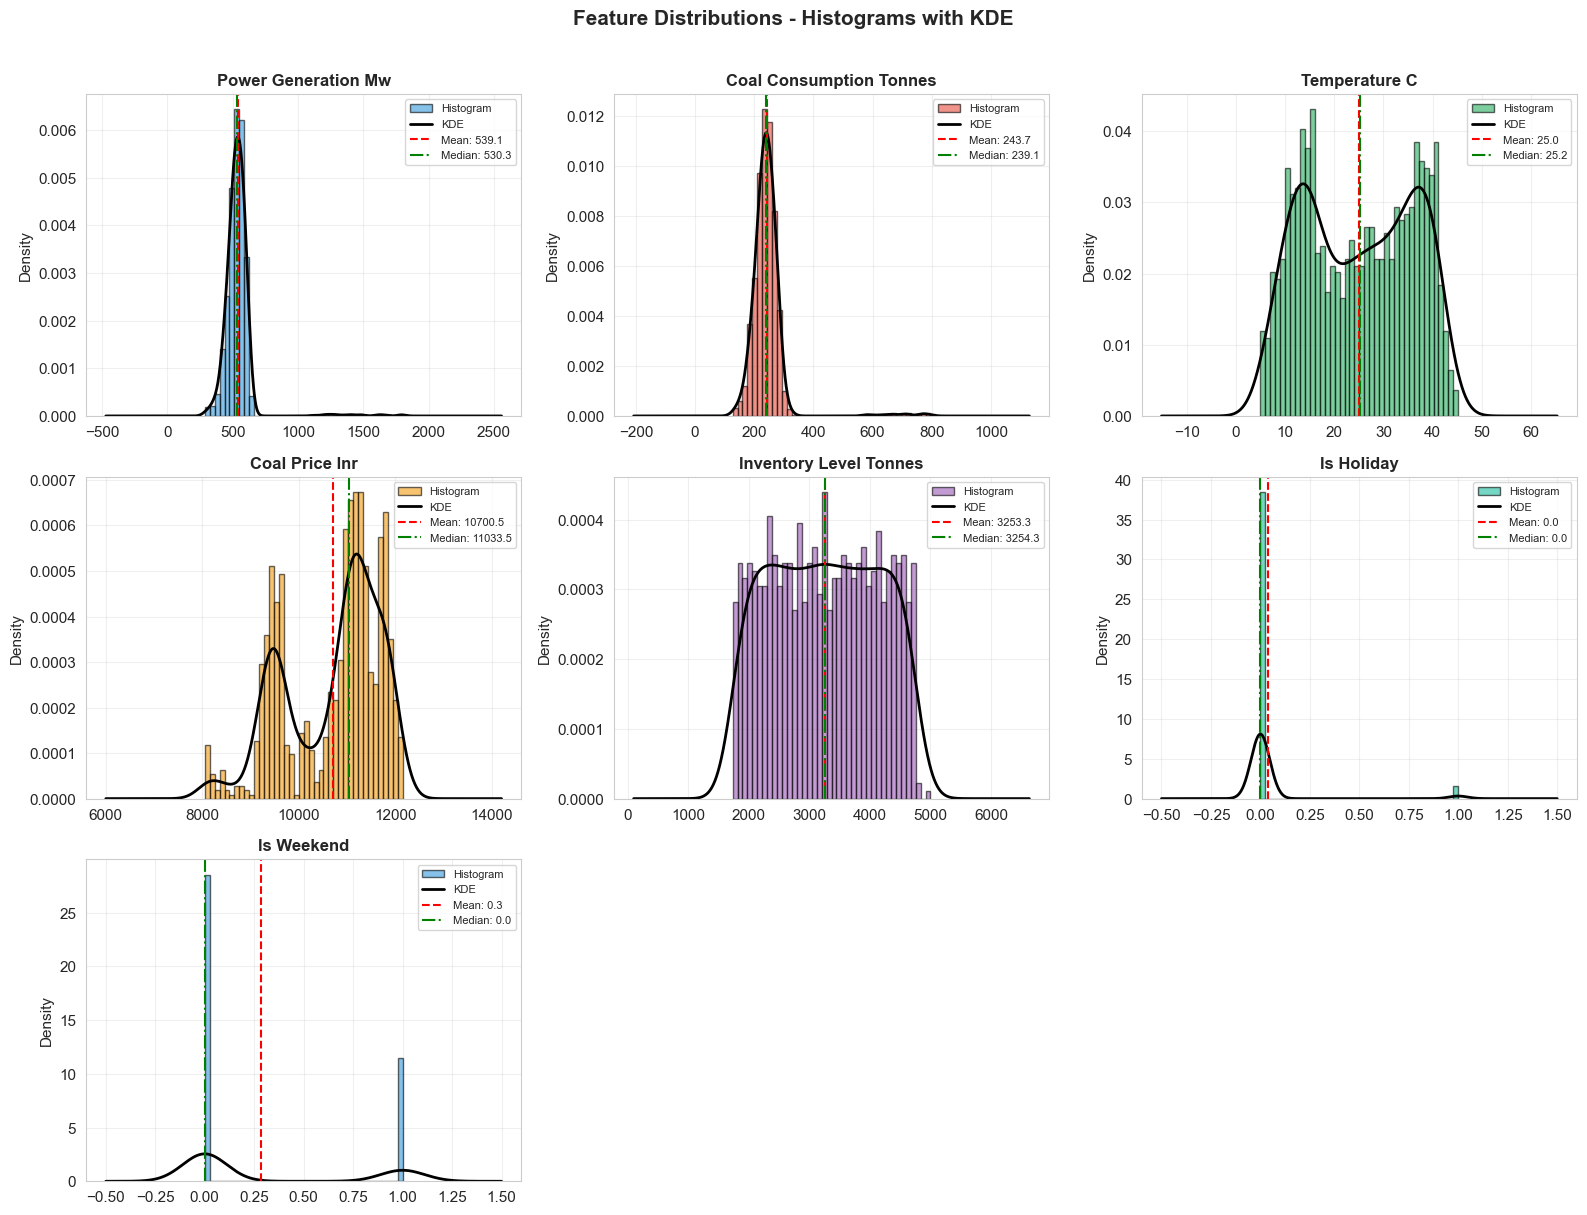


Skewness of numeric features:
  power_generation_mw            skew =   5.783  (HIGHLY skewed)
  coal_consumption_tonnes        skew =   5.392  (HIGHLY skewed)
  temperature_c                  skew =  -0.025  (symmetric)
  coal_price_inr                 skew =  -0.647  (moderate)
  inventory_level_tonnes         skew =   0.005  (symmetric)
  is_holiday                     skew =   4.816  (HIGHLY skewed)
  is_weekend                     skew =   0.946  (moderate)


In [7]:
# ── Distribution plots for all numeric columns ────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols_grid = 3
n_rows_grid = (len(numeric_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, 4 * n_rows_grid))
axes = axes.flatten()

colors_dist = ['#3498DB', '#E74C3C', '#27AE60', '#F39C12', '#9B59B6', '#1ABC9C']

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()
    color = colors_dist[idx % len(colors_dist)]
    
    # Histogram with KDE overlay
    ax.hist(data, bins=40, color=color, alpha=0.6, edgecolor='black', density=True, label='Histogram')
    data.plot.kde(ax=ax, color='black', linewidth=2, label='KDE')
    
    # Mark mean (red) and median (green)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='-.',  linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Distributions - Histograms with KDE',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print skewness for each feature
print("\nSkewness of numeric features:")
for col in numeric_cols:
    skew = df[col].dropna().skew()
    label = 'symmetric' if abs(skew) < 0.5 else ('moderate' if abs(skew) < 1 else 'HIGHLY skewed')
    print(f"  {col:<30} skew = {skew:>7.3f}  ({label})")

## 2.6 Time Series - Individual Features

Plotting each numeric feature as a time series to visually inspect trends, seasonality, and anomalies over the 3-year period. Red vertical lines mark missing values (if any).

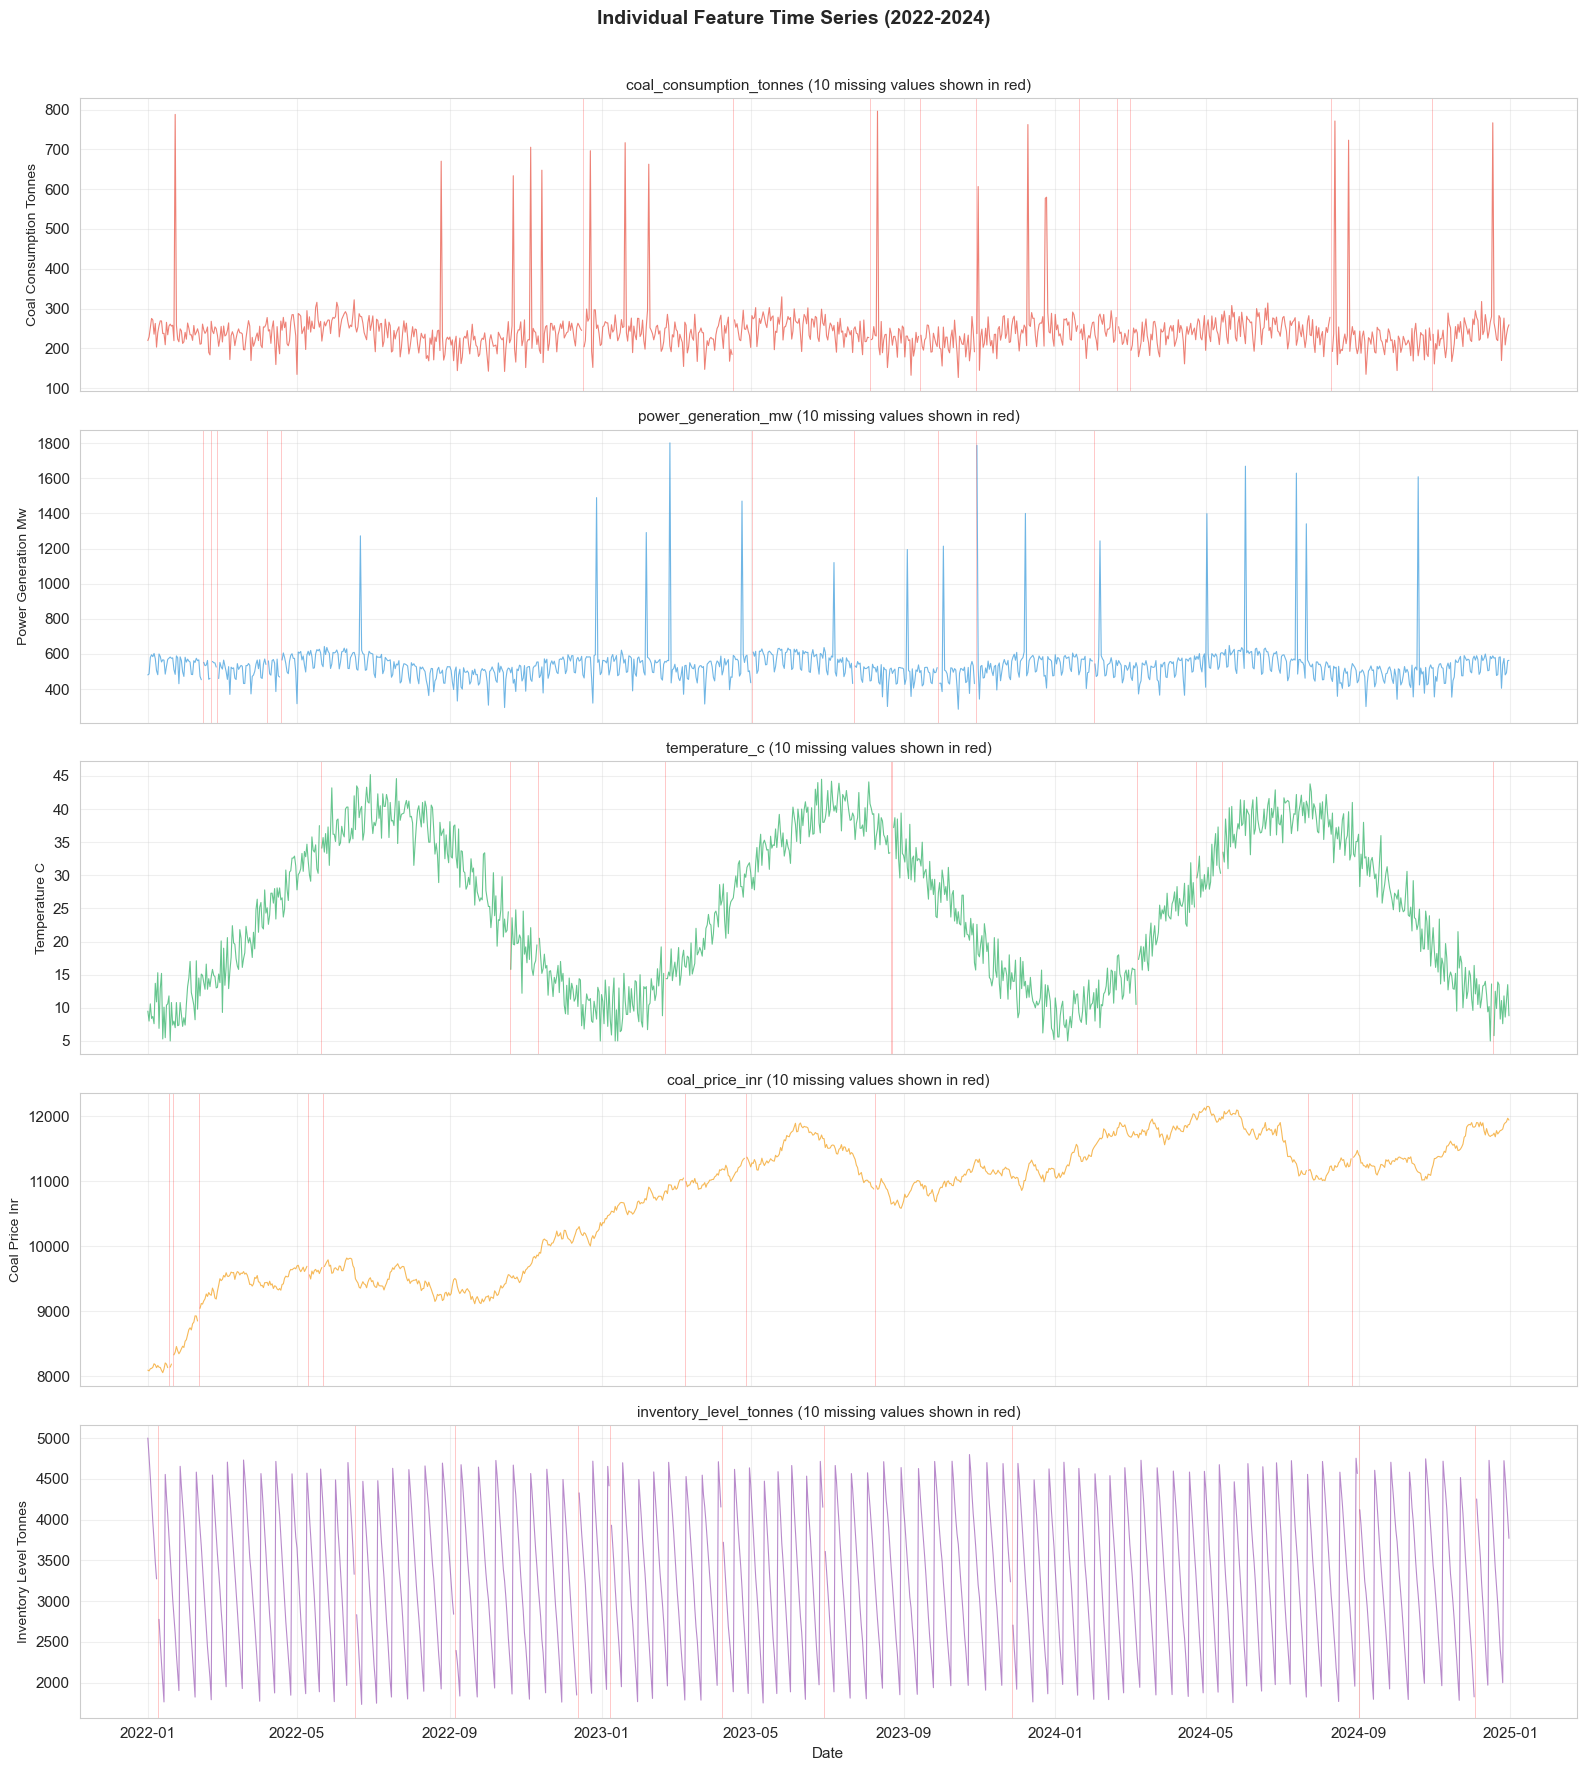

In [8]:
# ── Time series plots for each feature ────────────────────────────────────────
ts_cols = ['coal_consumption_tonnes', 'power_generation_mw', 'temperature_c',
           'coal_price_inr', 'inventory_level_tonnes']
ts_cols = [c for c in ts_cols if c in df.columns]  # keep only existing columns

fig, axes = plt.subplots(len(ts_cols), 1, figsize=(16, 3.5 * len(ts_cols)), sharex=True)
if len(ts_cols) == 1:
    axes = [axes]

colors_ts = ['#E74C3C', '#3498DB', '#27AE60', '#F39C12', '#9B59B6']

for idx, col in enumerate(ts_cols):
    ax = axes[idx]
    ax.plot(df['date'], df[col], color=colors_ts[idx], alpha=0.7, linewidth=0.8)
    ax.set_ylabel(col.replace('_', ' ').title(), fontsize=10)
    ax.grid(True, alpha=0.3)
    # Highlight missing values with red vertical lines
    missing_dates = df[df[col].isna()]['date']
    if len(missing_dates) > 0:
        for d in missing_dates:
            ax.axvline(d, color='red', alpha=0.3, linewidth=0.5)
        ax.set_title(f'{col} ({len(missing_dates)} missing values shown in red)', fontsize=11)
    else:
        ax.set_title(col.replace('_', ' ').title(), fontsize=11)

axes[-1].set_xlabel('Date')
plt.suptitle('Individual Feature Time Series (2022-2024)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'feature_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2.7 Trend Analysis

We plot the raw daily coal consumption alongside **30-day** and **90-day rolling means** to reveal underlying trends:
- Summer peaks (~May-Jun) — increased cooling demand drives power generation
- Winter peaks (~Dec-Jan) — heating demand
- Outlier spikes visible in the raw daily data are smoothed by the rolling averages

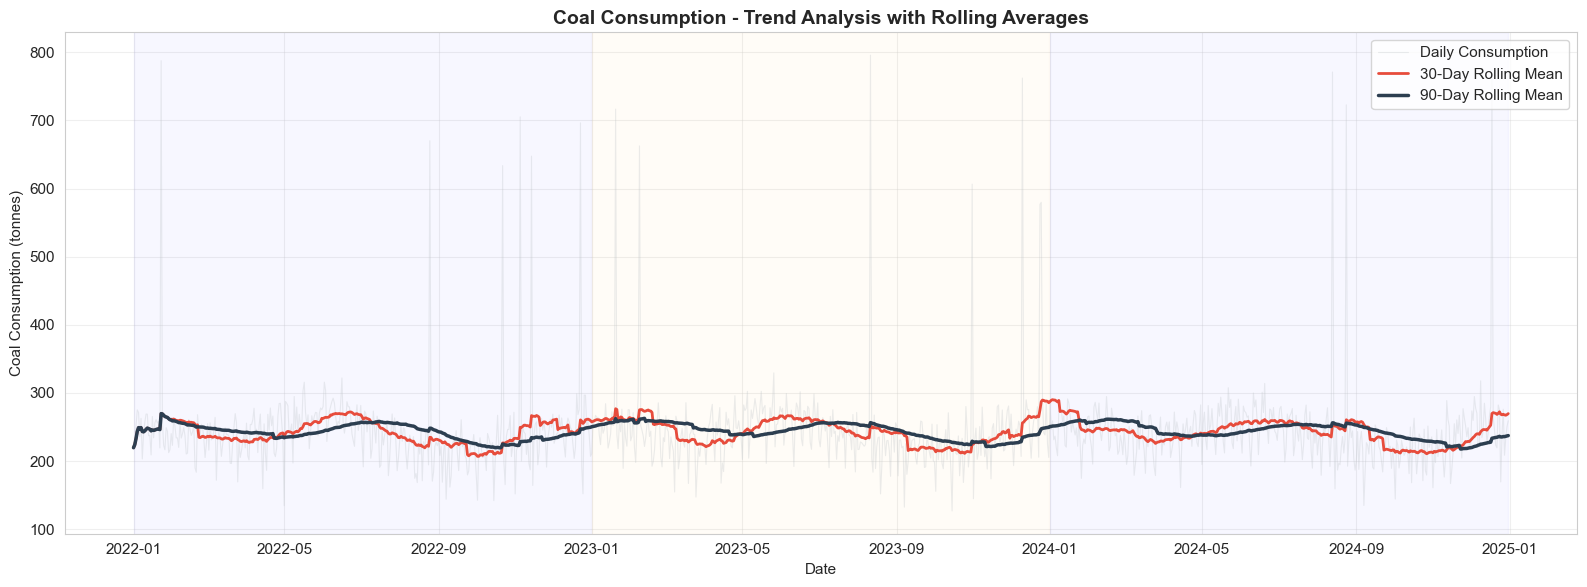

Mean daily consumption: 243.70 tonnes
Std deviation:         63.98 tonnes
Coefficient of Var:    26.26%
Min: 126.88 | Max: 795.89 tonnes


In [9]:
# ── Trend analysis with rolling means ─────────────────────────────────────────
df_ts = df.set_index('date')
coal = df_ts['coal_consumption_tonnes'].dropna()

rolling_30 = coal.rolling(window=30, min_periods=1).mean()
rolling_90 = coal.rolling(window=90, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(coal.index, coal.values, alpha=0.3, color='#BDC3C7', linewidth=0.8,
        label='Daily Consumption')
ax.plot(rolling_30.index, rolling_30.values, color='#E74C3C', linewidth=2,
        label='30-Day Rolling Mean')
ax.plot(rolling_90.index, rolling_90.values, color='#2C3E50', linewidth=2.5,
        label='90-Day Rolling Mean')

# Shade yearly regions for visual separation
for year in [2022, 2023, 2024]:
    ax.axvspan(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'),
               alpha=0.03, color='blue' if year % 2 == 0 else 'orange')

ax.set_title('Coal Consumption - Trend Analysis with Rolling Averages',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Coal Consumption (tonnes)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'trend_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# Key statistics
print(f"Mean daily consumption: {coal.mean():.2f} tonnes")
print(f"Std deviation:         {coal.std():.2f} tonnes")
print(f"Coefficient of Var:    {coal.std()/coal.mean()*100:.2f}%")
print(f"Min: {coal.min():.2f} | Max: {coal.max():.2f} tonnes")

## 2.8 Seasonality Decomposition

Using **additive decomposition** with period=365 (daily data) to separate the time series into:
- **Observed** — Original signal
- **Trend** — Long-term direction
- **Seasonal** — Repeating annual patterns
- **Residual** — Random noise after removing trend + seasonality

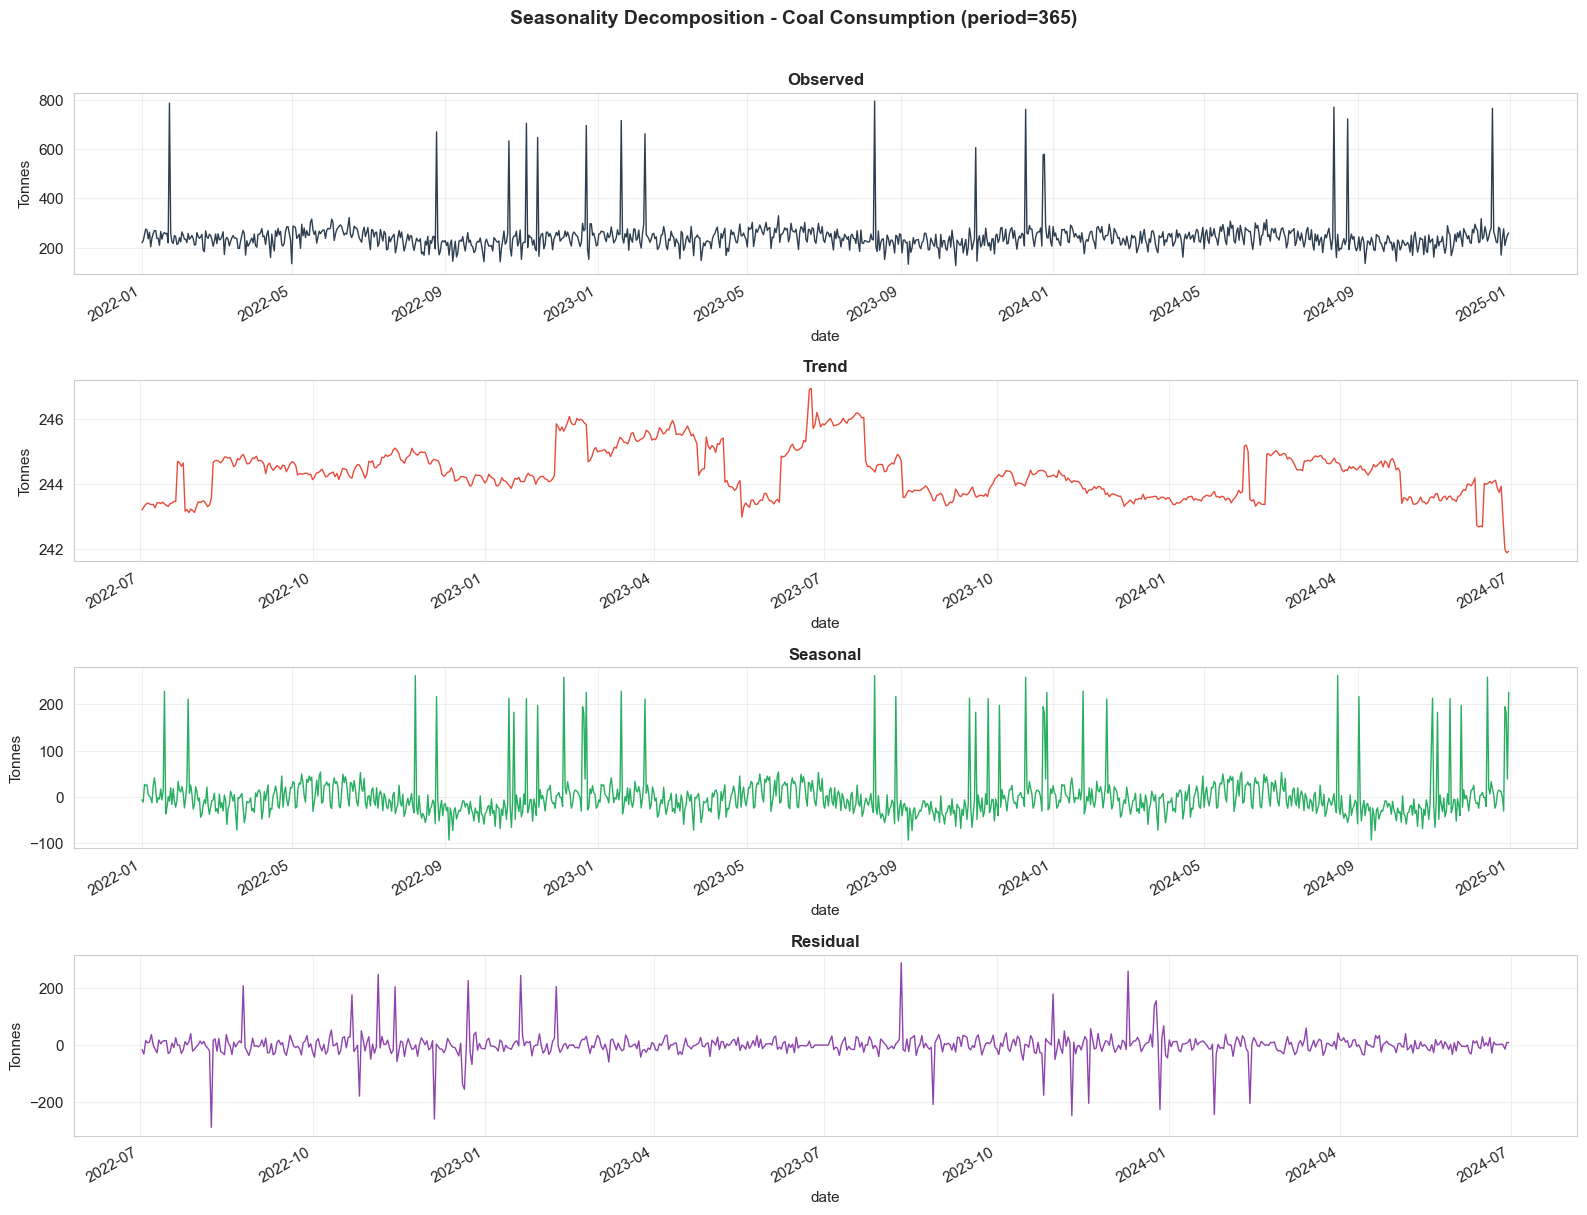

Seasonal amplitude: 354.50 tonnes (max seasonal swing)
Residual std: 43.83 tonnes


In [10]:
# ── Seasonality decomposition ─────────────────────────────────────────────────
series = df_ts['coal_consumption_tonnes'].dropna()
decomposition = seasonal_decompose(series, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
components = [
    (decomposition.observed, 'Observed', '#2C3E50'),
    (decomposition.trend,    'Trend',    '#E74C3C'),
    (decomposition.seasonal, 'Seasonal', '#27AE60'),
    (decomposition.resid,    'Residual', '#8E44AD'),
]

for ax, (comp, title, color) in zip(axes, components):
    comp.plot(ax=ax, color=color, linewidth=1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Tonnes')

plt.suptitle('Seasonality Decomposition - Coal Consumption (period=365)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'seasonality_decomposition.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Seasonal amplitude indicates the strength of the yearly cycle
seasonal_range = decomposition.seasonal.max() - decomposition.seasonal.min()
print(f"Seasonal amplitude: {seasonal_range:.2f} tonnes (max seasonal swing)")
print(f"Residual std: {decomposition.resid.dropna().std():.2f} tonnes")

## 2.9 Monthly & Weekly Consumption Patterns

Aggregating consumption by **month** and **day of week** to identify clear cyclical patterns that can inform feature engineering.

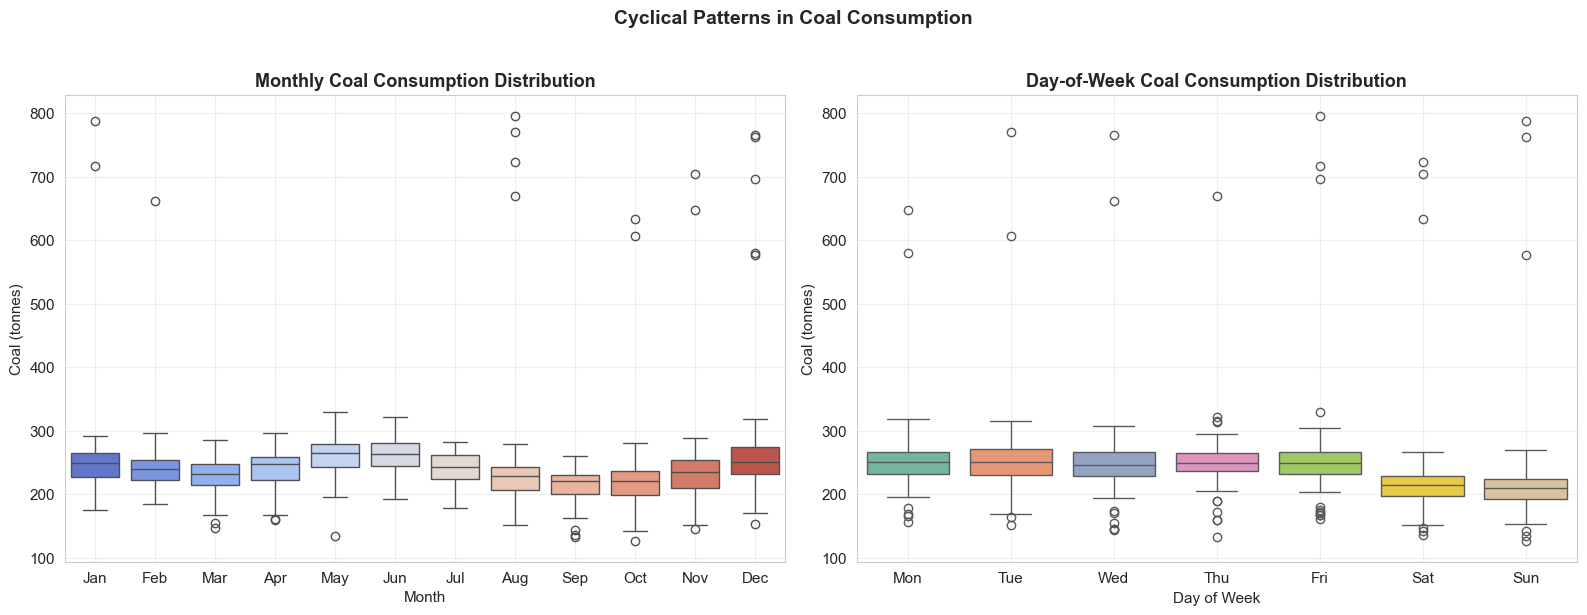

Monthly average consumption (tonnes):
  Month  1:  256.28  █████████████████████████
  Month  2:  244.49  ████████████████████████
  Month  3:  227.79  ██████████████████████
  Month  4:  241.16  ████████████████████████
  Month  5:  259.35  █████████████████████████
  Month  6:  261.98  ██████████████████████████
  Month  7:  239.51  ███████████████████████
  Month  8:  243.46  ████████████████████████
  Month  9:  214.89  █████████████████████
  Month 10:  223.93  ██████████████████████
  Month 11:  239.55  ███████████████████████
  Month 12:  270.99  ███████████████████████████


In [11]:
# ── Monthly and day-of-week patterns ──────────────────────────────────────────
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['month_name'] = df['date'].dt.strftime('%b')
df['dow_name'] = df['date'].dt.strftime('%a')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly consumption boxplot
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=df, x='month_name', y='coal_consumption_tonnes',
            order=month_order, palette='coolwarm', ax=axes[0])
axes[0].set_title('Monthly Coal Consumption Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Coal (tonnes)')
axes[0].grid(True, alpha=0.3)

# Day-of-week boxplot
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.boxplot(data=df, x='dow_name', y='coal_consumption_tonnes',
            order=dow_order, palette='Set2', ax=axes[1])
axes[1].set_title('Day-of-Week Coal Consumption Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Coal (tonnes)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Cyclical Patterns in Coal Consumption',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'monthly_weekly_patterns.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Monthly means in text
print("Monthly average consumption (tonnes):")
monthly_avg = df.groupby('month')['coal_consumption_tonnes'].mean()
for m, v in monthly_avg.items():
    bar = chr(9608) * int(v / 10)
    print(f"  Month {m:>2}: {v:>7.2f}  {bar}")

## 2.10 Quarterly Trends

Year-over-year quarterly comparison to see if overall consumption is growing, stable, or declining across the 3-year period.

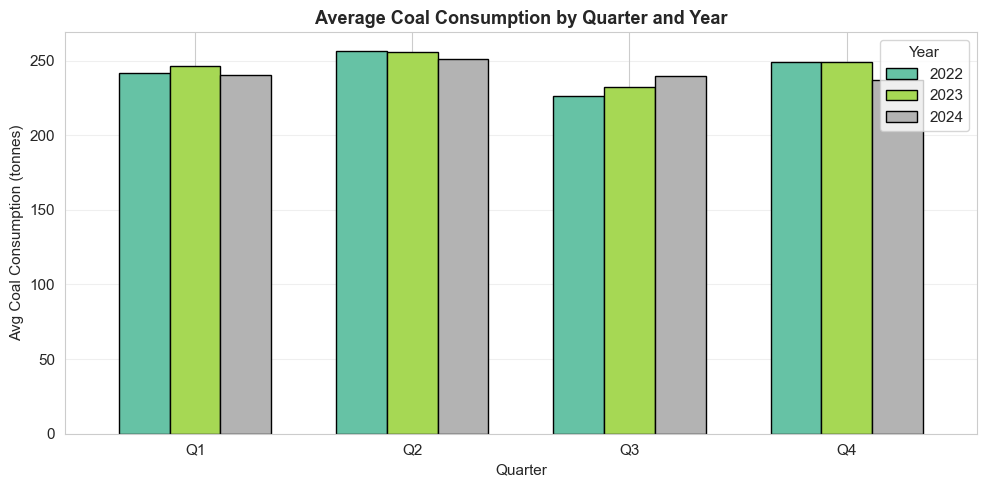

In [12]:
# ── Quarterly bar chart ───────────────────────────────────────────────────────
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year

quarterly = df.groupby(['year', 'quarter'])['coal_consumption_tonnes'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(10, 5))
quarterly.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)
ax.set_title('Average Coal Consumption by Quarter and Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Avg Coal Consumption (tonnes)')
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
ax.legend(title='Year')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'quarterly_trends.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 2.11 Holiday & Weekend Impact Analysis

Comparing coal consumption on **holidays vs non-holidays** and **weekends vs weekdays** using violin plots. Industrial operations often show reduced consumption on holidays and weekends.

Holiday avg:     173.76 tonnes
Non-holiday avg: 246.51 tonnes
Difference:      72.75 tonnes (29.5%)

Weekday avg:  253.21 tonnes
Weekend avg:  219.79 tonnes
Difference:   33.42 tonnes (13.2%)


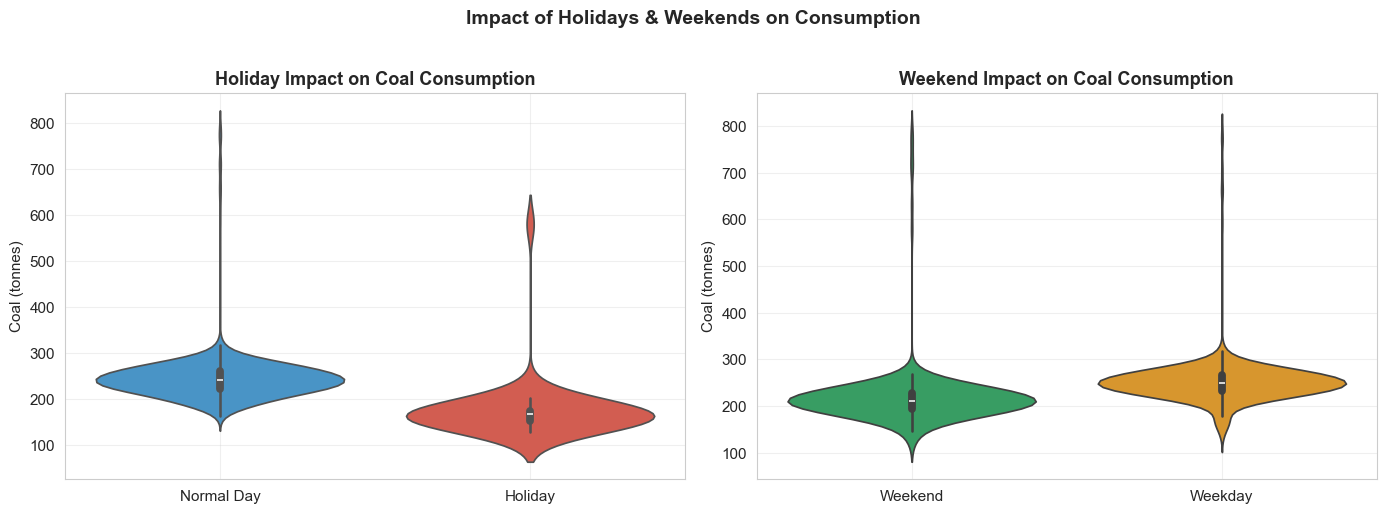

In [13]:
# ── Holiday and Weekend impact with violin plots ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Holiday impact
if 'is_holiday' in df.columns:
    holiday_labels = {0: 'Normal Day', 1: 'Holiday'}
    df['holiday_label'] = df['is_holiday'].map(holiday_labels)
    sns.violinplot(data=df, x='holiday_label', y='coal_consumption_tonnes',
                   palette=['#3498DB', '#E74C3C'], ax=axes[0], inner='box')
    axes[0].set_title('Holiday Impact on Coal Consumption',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Coal (tonnes)')
    axes[0].grid(True, alpha=0.3)
    
    holiday_mean = df[df['is_holiday']==1]['coal_consumption_tonnes'].mean()
    normal_mean  = df[df['is_holiday']==0]['coal_consumption_tonnes'].mean()
    print(f"Holiday avg:     {holiday_mean:.2f} tonnes")
    print(f"Non-holiday avg: {normal_mean:.2f} tonnes")
    print(f"Difference:      {normal_mean - holiday_mean:.2f} tonnes "
          f"({(normal_mean - holiday_mean)/normal_mean*100:.1f}%)")

# Weekend impact
if 'is_weekend' in df.columns:
    weekend_labels = {0: 'Weekday', 1: 'Weekend'}
    df['weekend_label'] = df['is_weekend'].map(weekend_labels)
    sns.violinplot(data=df, x='weekend_label', y='coal_consumption_tonnes',
                   palette=['#27AE60', '#F39C12'], ax=axes[1], inner='box')
    axes[1].set_title('Weekend Impact on Coal Consumption',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Coal (tonnes)')
    axes[1].grid(True, alpha=0.3)
    
    weekend_mean = df[df['is_weekend']==1]['coal_consumption_tonnes'].mean()
    weekday_mean = df[df['is_weekend']==0]['coal_consumption_tonnes'].mean()
    print(f"\nWeekday avg:  {weekday_mean:.2f} tonnes")
    print(f"Weekend avg:  {weekend_mean:.2f} tonnes")
    print(f"Difference:   {weekday_mean - weekend_mean:.2f} tonnes "
          f"({(weekday_mean-weekend_mean)/weekday_mean*100:.1f}%)")

plt.suptitle('Impact of Holidays & Weekends on Consumption',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'holiday_weekend_impact.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 2.12 ACF & PACF Plots

**Autocorrelation (ACF)** and **Partial Autocorrelation (PACF)** plots help determine:
- **ACF** — order of MA(q) terms for ARIMA; slow decay suggests non-stationarity
- **PACF** — order of AR(p) terms for ARIMA; significant lags indicate autoregressive patterns
- Significant lags at 7, 14, 30 indicate weekly/monthly temporal dependencies

We also run the **Augmented Dickey-Fuller (ADF)** test for stationarity.

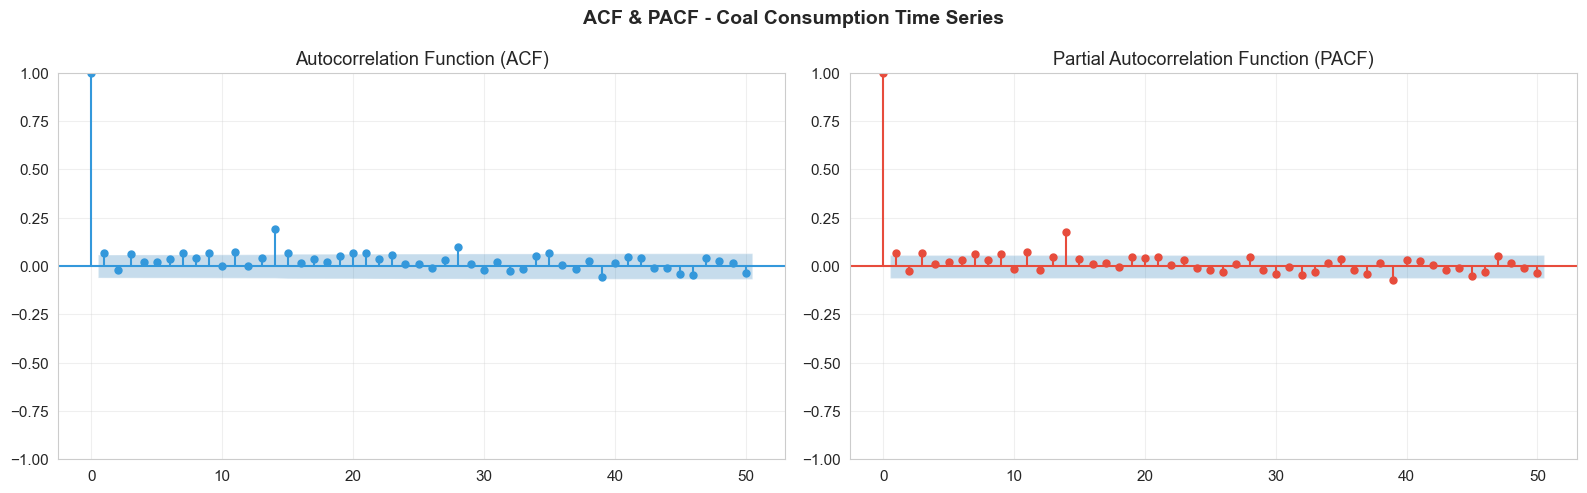

ADF Statistic: -5.4628
p-value:       0.000002
Stationary:    YES (p < 0.05 required)


In [14]:
# ── ACF & PACF plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(series, ax=axes[0], lags=50,
         title='Autocorrelation Function (ACF)',
         color='#3498DB', vlines_kwargs={'colors': '#3498DB'})
plot_pacf(series, ax=axes[1], lags=50,
          title='Partial Autocorrelation Function (PACF)',
          color='#E74C3C', vlines_kwargs={'colors': '#E74C3C'})

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('ACF & PACF - Coal Consumption Time Series',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'acf_pacf.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Augmented Dickey-Fuller test
adf_result = adfuller(series, autolag='AIC')
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.6f}")
print(f"Stationary:    {'YES' if adf_result[1] < 0.05 else 'NO'} (p < 0.05 required)")

## 2.13 Correlation Heatmap

Examining feature inter-relationships to understand which variables most influence coal consumption and to identify potential **multicollinearity** issues for regression-based models.

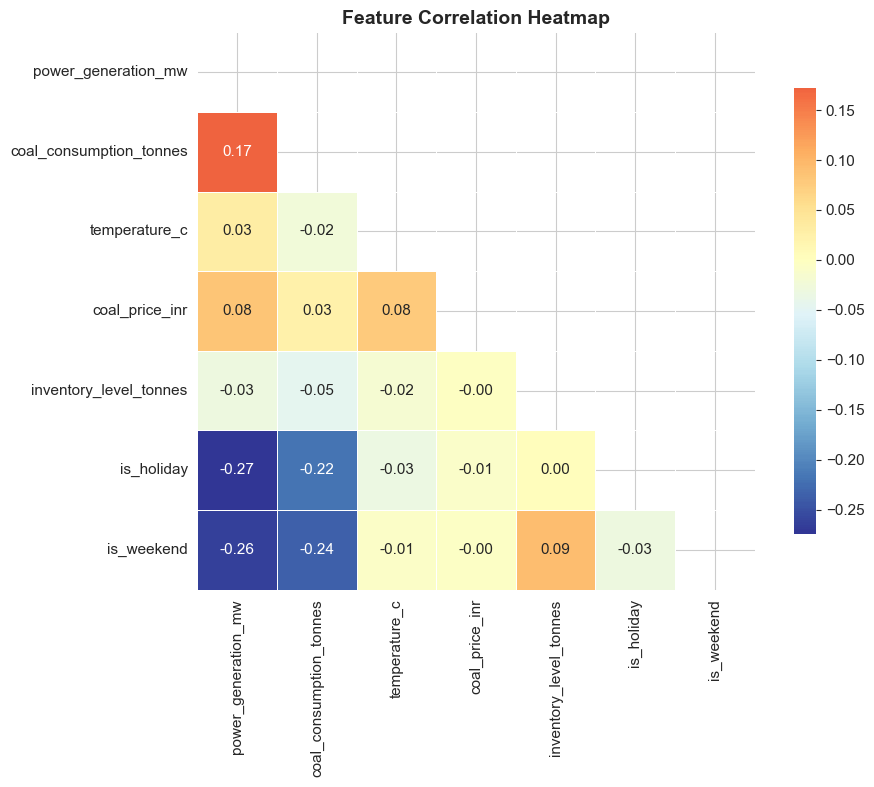


Correlation with coal_consumption_tonnes (target):
  power_generation_mw            r =  0.1721  (weak)
  coal_price_inr                 r =  0.0252  (weak)
  temperature_c                  r = -0.0237  (weak)
  inventory_level_tonnes         r = -0.0467  (weak)
  is_holiday                     r = -0.2193  (weak)
  is_weekend                     r = -0.2358  (weak)


In [15]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
# Exclude derived temporary columns from the correlation matrix
exclude = ['month', 'day_of_week', 'quarter', 'year',
           'month_name', 'dow_name', 'holiday_label', 'weekend_label']
corr_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in exclude]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, ax=ax, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Correlations with target sorted by absolute value
if 'coal_consumption_tonnes' in corr_matrix.columns:
    target_corr = corr_matrix['coal_consumption_tonnes'].drop(
        'coal_consumption_tonnes').sort_values(ascending=False)
    print("\nCorrelation with coal_consumption_tonnes (target):")
    for feat, val in target_corr.items():
        strength = ('STRONG' if abs(val) > 0.5
                    else ('moderate' if abs(val) > 0.3 else 'weak'))
        print(f"  {feat:<30} r = {val:>7.4f}  ({strength})")

## 2.14 Pairplot - Key Variable Relationships

Scatter plots of the most important predictors against the target variable, with trend lines to visualize linear relationships.

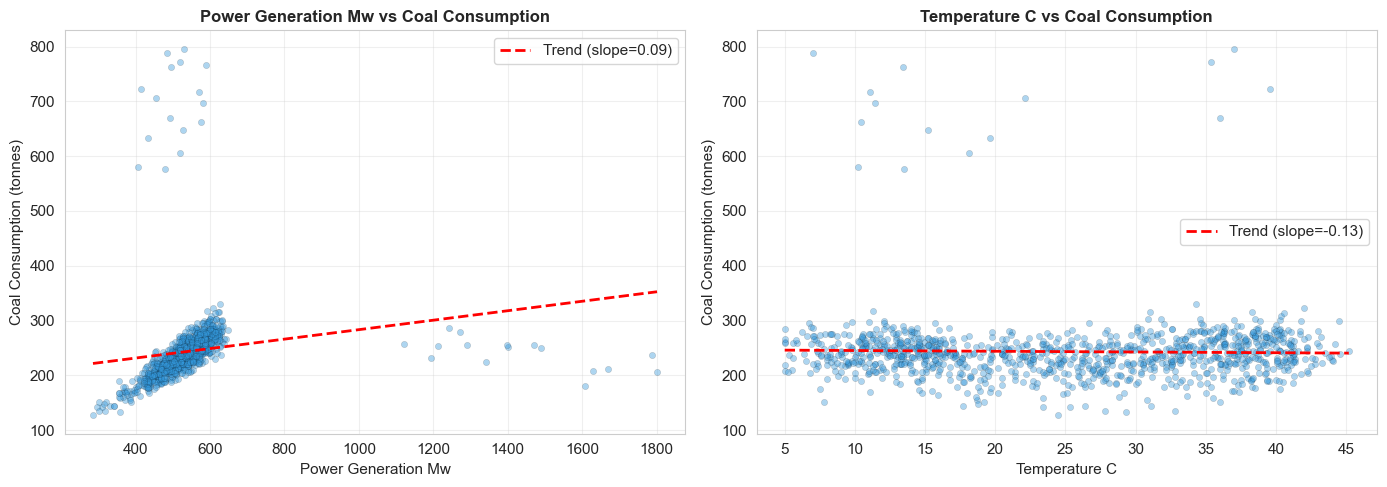

In [16]:
# ── Scatter plots with trend lines ────────────────────────────────────────────
pair_cols = ['coal_consumption_tonnes', 'power_generation_mw', 'temperature_c']
pair_cols = [c for c in pair_cols if c in df.columns]

if len(pair_cols) >= 2:
    n_plots = len(pair_cols) - 1
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    
    for idx, col in enumerate(pair_cols[1:]):
        ax = axes[idx]
        valid = df[[col, 'coal_consumption_tonnes']].dropna()
        ax.scatter(valid[col], valid['coal_consumption_tonnes'], alpha=0.4,
                   color='#3498DB', edgecolor='black', linewidth=0.2, s=20)
        # Fit and draw trend line
        z = np.polyfit(valid[col], valid['coal_consumption_tonnes'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--',
                label=f'Trend (slope={z[0]:.2f})')
        ax.set_xlabel(col.replace('_', ' ').title())
        ax.set_ylabel('Coal Consumption (tonnes)')
        ax.set_title(f'{col.replace("_"," ").title()} vs Coal Consumption',
                     fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'pairplot.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 2.15 Outlier Detection - Boxplots

Using the **IQR (Interquartile Range)** method to detect outliers:
- Lower bound = Q1 - 1.5 x IQR
- Upper bound = Q3 + 1.5 x IQR
- Points beyond these bounds are flagged as outliers

Knowing the number and location of outliers helps decide on capping/winsorization during preprocessing.

Outlier Summary (IQR method):
  coal_consumption_tonnes          33 outliers  (3.0%)  bounds: [158.9, 320.2]
  power_generation_mw              40 outliers  (3.7%)  bounds: [373.0, 691.9]
  temperature_c                     0 outliers  (0.0%)  bounds: [-16.1, 66.2]
  coal_price_inr                    0 outliers  (0.0%)  bounds: [7029.3, 14061.2]
  inventory_level_tonnes            0 outliers  (0.0%)  bounds: [253.2, 6270.3]


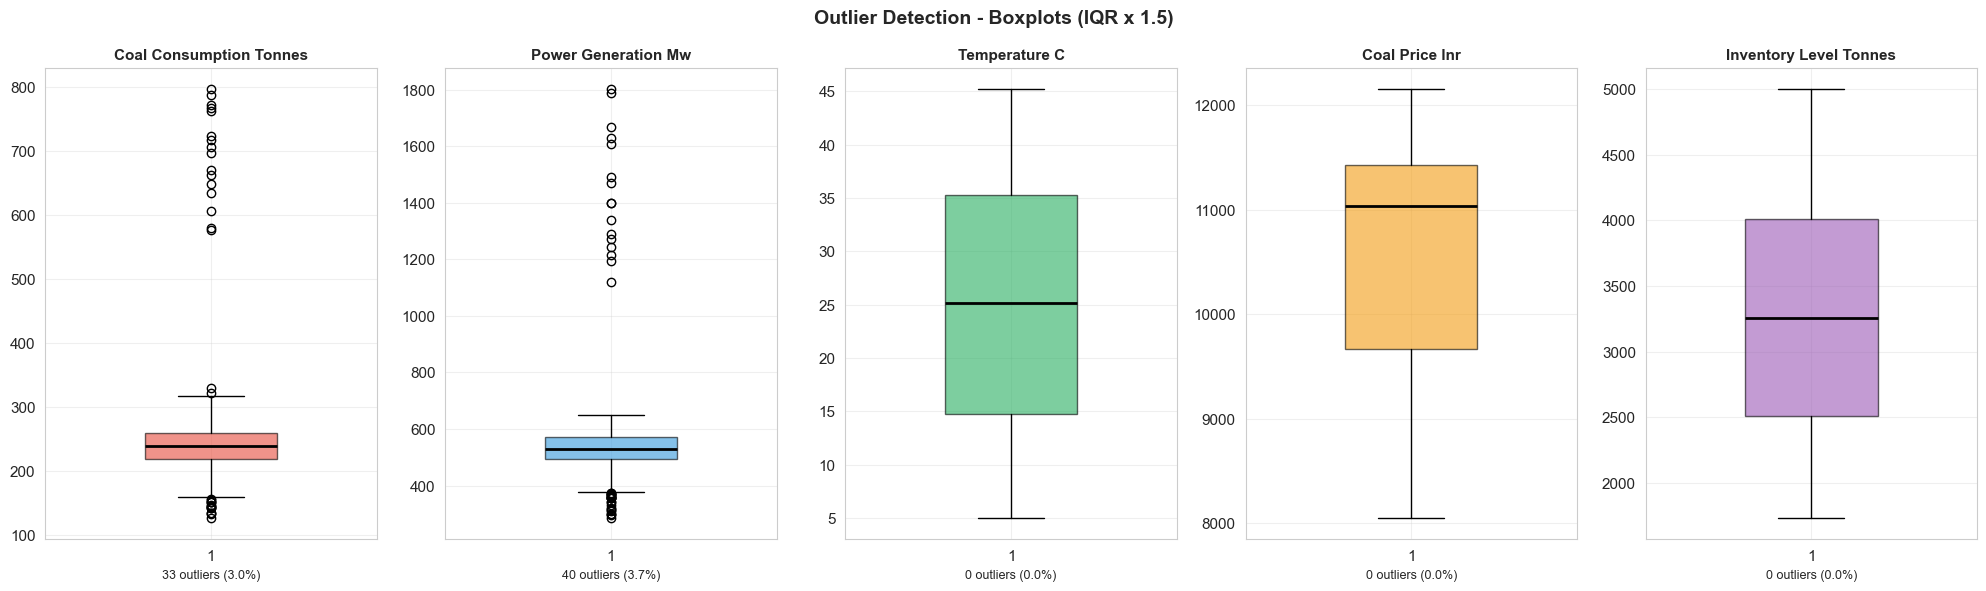

In [17]:
# ── Outlier detection boxplots ────────────────────────────────────────────────
outlier_cols = ['coal_consumption_tonnes', 'power_generation_mw',
                'temperature_c', 'coal_price_inr', 'inventory_level_tonnes']
outlier_cols = [c for c in outlier_cols if c in df.columns]

colors_bp = ['#E74C3C', '#3498DB', '#27AE60', '#F39C12', '#9B59B6']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4 * len(outlier_cols), 6))
if len(outlier_cols) == 1:
    axes = [axes]

print("Outlier Summary (IQR method):")
print("=" * 55)
for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    bp = axes[i].boxplot(data, patch_artist=True, widths=0.4,
                         boxprops=dict(facecolor=colors_bp[i], alpha=0.6),
                         medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    
    # Count outliers using IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - IQR_MULTIPLIER * iqr
    upper_bound = q3 + IQR_MULTIPLIER * iqr
    n_outliers = ((data < lower_bound) | (data > upper_bound)).sum()
    axes[i].set_xlabel(f'{n_outliers} outliers ({n_outliers/len(data)*100:.1f}%)',
                       fontsize=9)
    
    print(f"  {col:<30} {n_outliers:>4} outliers  ({n_outliers/len(data)*100:.1f}%)  "
          f"bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")

plt.suptitle(f'Outlier Detection - Boxplots (IQR x {IQR_MULTIPLIER})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'outlier_boxplots.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 2.16 Missing Values Visualization

Visualizing the **count** and **pattern** of missing values in the dataset. The pattern matrix shows whether missing values are random or systematic (e.g., contiguous blocks).

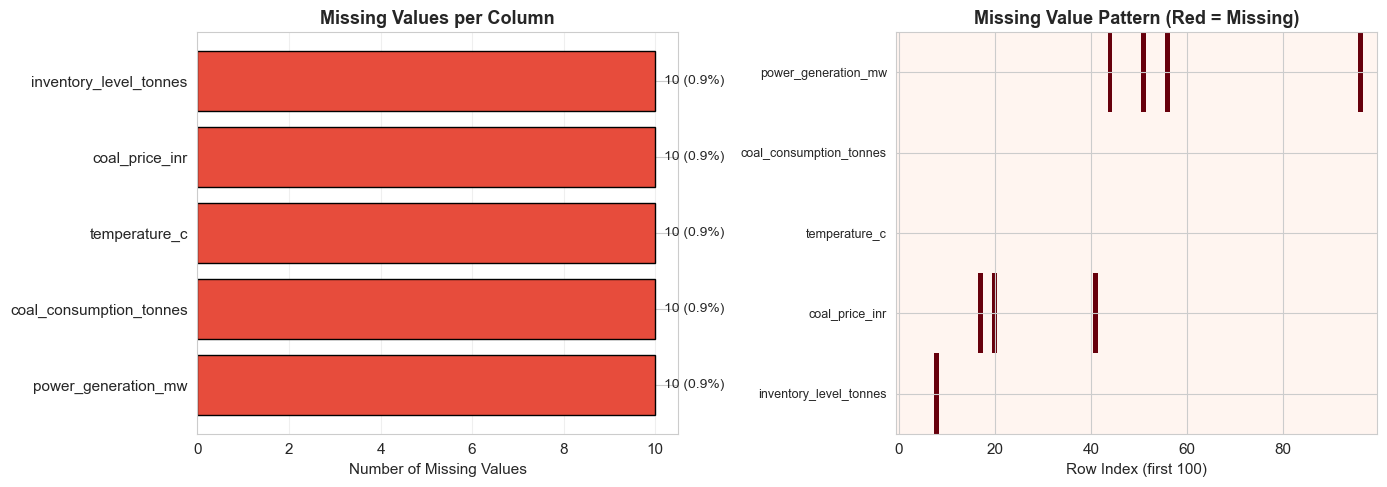


Total missing values: 50
Total cells: 17536
Missing %: 0.29%


In [18]:
# ── Missing values visualization ──────────────────────────────────────────────
missing_vals = df.isnull()
missing_counts = missing_vals.sum()
cols_with_missing = missing_counts[missing_counts > 0].index.tolist()

if len(cols_with_missing) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of missing counts
    axes[0].barh(cols_with_missing, missing_counts[cols_with_missing],
                 color='#E74C3C', edgecolor='black')
    axes[0].set_xlabel('Number of Missing Values')
    axes[0].set_title('Missing Values per Column', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(missing_counts[cols_with_missing]):
        axes[0].text(v + 0.2, i, f'{v} ({v/len(df)*100:.1f}%)',
                     va='center', fontsize=10)
    
    # Missing pattern matrix (first 100 rows)
    sample_missing = missing_vals[cols_with_missing].head(100)
    axes[1].imshow(sample_missing.T, cmap='Reds', aspect='auto',
                   interpolation='nearest')
    axes[1].set_yticks(range(len(cols_with_missing)))
    axes[1].set_yticklabels(cols_with_missing, fontsize=9)
    axes[1].set_xlabel('Row Index (first 100)')
    axes[1].set_title('Missing Value Pattern (Red = Missing)',
                      fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'missing_values.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No missing values found in the dataset.")

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total cells: {df.size}")
print(f"Missing %: {df.isnull().sum().sum() / df.size * 100:.2f}%")

## 2.17 Data Issues Report

Comprehensive text report covering:
- **Missing values** per column with counts and percentages
- **Outliers** detected via IQR method
- **Stationarity** test (ADF)
- **Skewness** analysis for each numeric feature
- **Recommended preprocessing fixes** based on all findings

In [19]:
# ── Data Issues Report (fully inline — no external .py dependency) ────────────
print("=" * 70)
print("           DATA ISSUES REPORT - Coal Demand Forecasting")
print("=" * 70)

# --- Missing Values ---
print("\n  MISSING VALUES:")
print("  " + "-" * 40)
total_missing = 0
for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        pct = n_missing / len(df) * 100
        print(f"    {col}: {n_missing} ({pct:.2f}%)")
        total_missing += n_missing
if total_missing == 0:
    print("    None found")
else:
    print(f"    TOTAL: {total_missing} missing values")

# --- Outliers ---
print("\n  OUTLIERS (IQR Method):")
print("  " + "-" * 40)
num_cols = df.select_dtypes(include=[np.number]).columns
total_outliers_count = 0
for col in num_cols:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - IQR_MULTIPLIER * iqr) |
             (data > q3 + IQR_MULTIPLIER * iqr)).sum()
    if n_out > 0:
        print(f"    {col}: {n_out} outliers ({n_out/len(data)*100:.2f}%)")
        total_outliers_count += n_out
print(f"    TOTAL: {total_outliers_count} outliers")

# --- Stationarity (ADF Test) ---
print("\n  STATIONARITY (ADF Test):")
print("  " + "-" * 40)
if 'coal_consumption_tonnes' in df.columns:
    adf = adfuller(df['coal_consumption_tonnes'].dropna(), autolag='AIC')
    is_stat = 'YES' if adf[1] < 0.05 else 'NO'
    print(f"    Target (coal_consumption_tonnes):")
    print(f"      ADF Statistic: {adf[0]:.4f}")
    print(f"      p-value: {adf[1]:.6f}")
    print(f"      Stationary: {is_stat}")

# --- Skewness ---
print("\n  SKEWNESS:")
print("  " + "-" * 40)
for col in num_cols:
    skew_val = df[col].dropna().skew()
    label = ('approximately symmetric' if abs(skew_val) < 0.5
             else ('moderately skewed' if abs(skew_val) < 1 else 'HIGHLY SKEWED'))
    print(f"    {col}: {skew_val:.4f} ({label})")

# --- Recommended Fixes ---
print("\n  RECOMMENDED PREPROCESSING FIXES:")
print("  " + "-" * 40)
print("    1. Forward-fill missing values (time-series appropriate)")
print("    2. Cap outliers at IQR bounds (winsorization)")
print("    3. Add lag features (1, 7, 30 days)")
print("    4. Add rolling statistics (mean, std)")
print("    5. Engineer calendar features (month, quarter, day_of_week)")
if 'coal_consumption_tonnes' in df.columns:
    p_val = adfuller(df['coal_consumption_tonnes'].dropna())[1]
    if p_val >= 0.05:
        print("    6. Apply differencing for stationarity (ARIMA)")

print("\n" + "=" * 70)
print("\nEDA Complete. All visualizations generated and saved.")
print(f"Reports saved to: {REPORTS_DIR}/")

           DATA ISSUES REPORT - Coal Demand Forecasting

  MISSING VALUES:
  ----------------------------------------
    power_generation_mw: 10 (0.91%)
    coal_consumption_tonnes: 10 (0.91%)
    temperature_c: 10 (0.91%)
    coal_price_inr: 10 (0.91%)
    inventory_level_tonnes: 10 (0.91%)
    TOTAL: 50 missing values

  OUTLIERS (IQR Method):
  ----------------------------------------
    power_generation_mw: 40 outliers (3.68%)
    coal_consumption_tonnes: 33 outliers (3.04%)
    is_holiday: 42 outliers (3.83%)
    TOTAL: 115 outliers

  STATIONARITY (ADF Test):
  ----------------------------------------
    Target (coal_consumption_tonnes):
      ADF Statistic: -5.4628
      p-value: 0.000002
      Stationary: YES

  SKEWNESS:
  ----------------------------------------
    power_generation_mw: 5.7827 (HIGHLY SKEWED)
    coal_consumption_tonnes: 5.3920 (HIGHLY SKEWED)
    temperature_c: -0.0251 (approximately symmetric)
    coal_price_inr: -0.6475 (moderately skewed)
    inventory

In [20]:
# ── Cleanup temporary columns added during EDA ────────────────────────────────
drop_cols = [c for c in ['month', 'day_of_week', 'month_name', 'dow_name',
                         'quarter', 'year', 'holiday_label', 'weekend_label']
             if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Cleaned up {len(drop_cols)} temporary columns.")
print(f"Final DataFrame shape: {df.shape}")

Cleaned up 8 temporary columns.
Final DataFrame shape: (1096, 8)
